In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [3]:
video_path = "videoplayback.mp4"
cap = cv2.VideoCapture(video_path)

In [4]:
frame_diffs = []
prev_gray = None
fps = cap.get(cv2.CAP_PROP_FPS)
print("Processing video...")

Processing video...


In [5]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is not None:
        diff = cv2.absdiff(prev_gray, gray)
        score = np.sum(diff) / diff.size
        frame_diffs.append(score)

    prev_gray = gray

cap.release()

print("Video processing complete!")

Video processing complete!


In [6]:
time_axis = np.arange(len(frame_diffs)) / fps

In [7]:
motion = np.array(frame_diffs)
motion = (motion - motion.min()) / (motion.max() - motion.min())

In [11]:
ffmpeg_path = "C:/ffmpeg/bin/ffmpeg.exe"

import os
os.system(f'"{ffmpeg_path}" -i {video_path} -q:a 0 -map a audio.wav -y')

0

In [13]:
y, sr = librosa.load("audio.wav", sr=None)

In [14]:
print(len(y), sr)

15474688 44100


In [15]:
rms = librosa.feature.rms(y=y)[0]

audio = (rms - rms.min()) / (rms.max() - rms.min())

In [17]:
import numpy as np

audio = np.convolve(audio, np.ones(10)/10, mode='same')

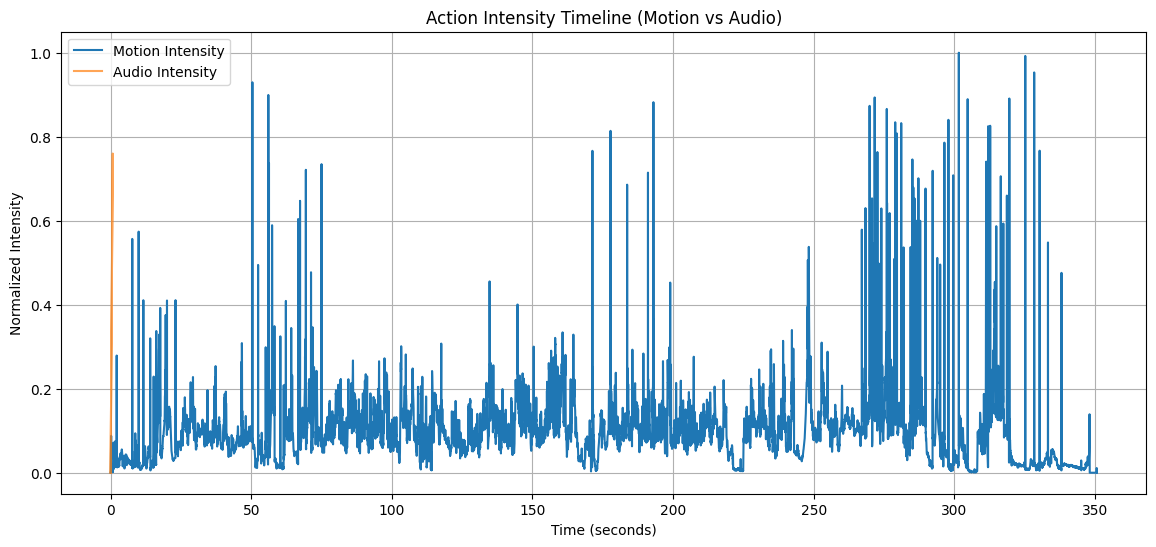

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(time_axis, motion, label="Motion Intensity")
plt.plot(audio, audio, label="Audio Intensity", alpha=0.7)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Intensity")
plt.title("Action Intensity Timeline (Motion vs Audio)")
plt.legend()
plt.grid()

plt.show()

In [20]:
threshold = 0.8

peak_times = time_axis[motion > threshold]

print("🔥 High-intensity moments (seconds):")
print(np.round(peak_times[:20], 2))

🔥 High-intensity moments (seconds):
[ 50.42  56.09 177.78 193.03 269.9  271.71 276.01 279.01 279.61 281.15
 297.93 301.63 304.77 312.08 312.78 319.59 325.26 328.43]


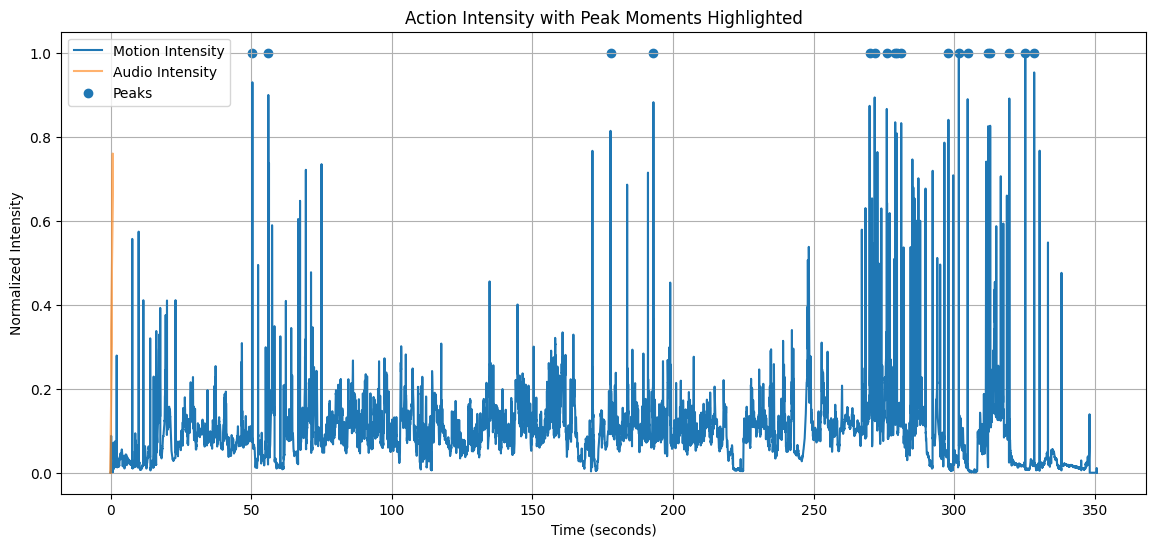

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(time_axis, motion, label="Motion Intensity")
plt.plot(audio, audio, label="Audio Intensity", alpha=0.6)

# mark peaks
plt.scatter(peak_times, [1]*len(peak_times), marker='o', label="Peaks")

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Intensity")
plt.title("Action Intensity with Peak Moments Highlighted")
plt.legend()
plt.grid()

plt.show()

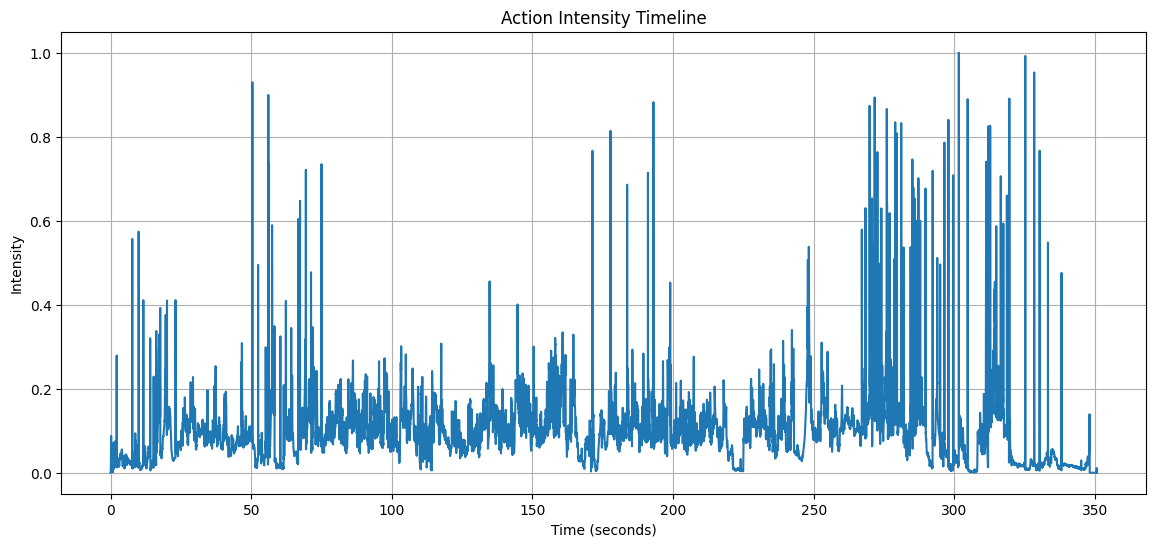

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(time_axis, motion)
plt.title("Action Intensity Timeline")
plt.xlabel("Time (seconds)")
plt.ylabel("Intensity")
plt.grid()

plt.savefig("final_plot.png", dpi=300)

In [24]:
correlation = np.corrcoef(motion[:len(audio)], audio[:len(motion)])[0,1]
print("Correlation between motion and audio:", round(correlation, 2))

Correlation between motion and audio: 0.05
